# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Example solution for Q1**

1. We use general linear models and activation functions when the relationship between inputs and outputs is not well represented by a plain linear prediction. For binary outcomes, a linear model can predict values below 0 or above 1, which do not make sense as probabilities. Logistic regression fixes this by applying a nonlinear activation function to a linear score.

2. Binary and categorical cross entropy are effective because they directly compare predicted probabilities to the true labels. They reward confident correct predictions and strongly penalize confident wrong predictions, which makes them well matched to classification problems.

3. Logistic regression is not a linear model. It is linear in the latent variable, because the model uses `b0 + b1 x1 + ... + bk xk`. But it is nonlinear in the predicted probability because that score is passed through the logistic activation function.

4. False. Logistic regression is one of the standard methods for classification. It outputs probabilities, and those probabilities can be converted into class labels.

5. Not directly in the predicted probability. In a linear model, a coefficient is the change in the prediction for a one-unit increase in a feature. In logistic regression, the coefficient is the change in the log-odds, not the probability itself.

6. False. Feature engineering can still matter a lot in logistic regression. If the relationship is not approximately linear in the log-odds, then transformations, interactions, or recoding variables can improve the model.

7. False. Logistic regression is better when the outcome is categorical, especially binary, but ordinary least squares is still appropriate for numeric outcomes. The choice depends on the problem.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


Missing values by column:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Logistic regression coefficients:
                   feature  coefficient
0                   Debtor     0.527137
1  Tuition fees up to date    -2.605617
2       Scholarship holder    -1.242299
3        Age at enrollment     0.049841

Average effect of being up to date on tuition on dropout probability:
-0.5233479701685047

Ages where tuition status reduces dropout probability the most:
Age at enrollment
22   -0.544791
21   -0.543064
23   -0.542678
20   -0.540436
24   -0.538071
19   -0.537309
18   -0.534191
25   -0.534188
26   -0.533585
27   -0.530360
Name: tuition_effect, dtype: float64


/home/trj/miniconda3/envs/hmm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


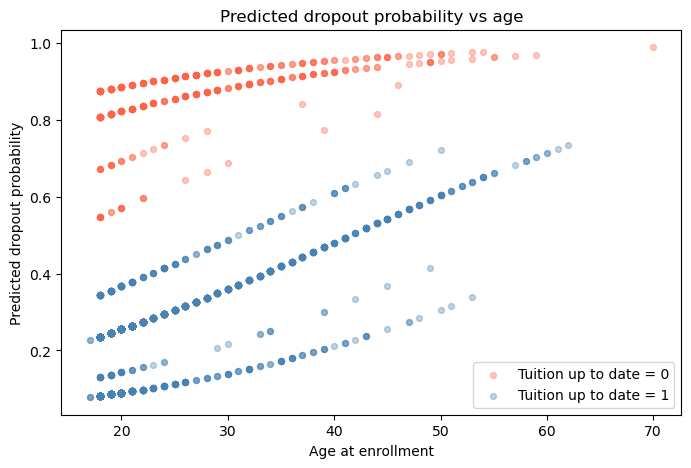


Logistic regression confusion matrix:
[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


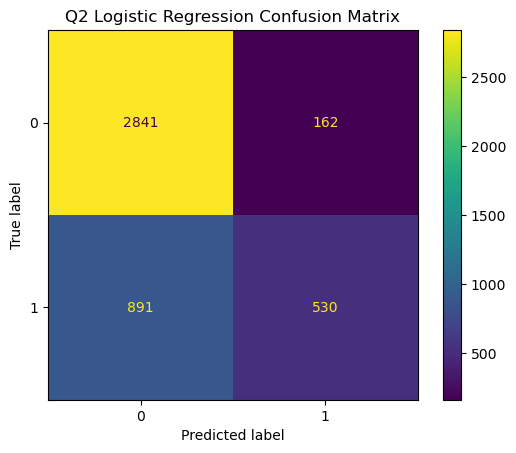


Linear model accuracy: 0.7633363471971067
Range of linear-model predictions: (0.05832035022573756, 1.3349535706758826)


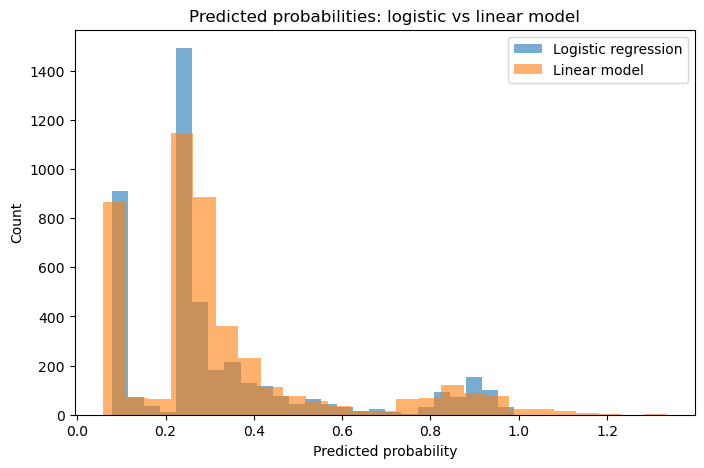


Multinomial confusion matrix (rows=true, cols=predicted):
          Dropout  Enrolled  Graduate
Dropout      1054         0       367
Enrolled      280         0       514
Graduate      146         0      2063

Predicted classes used by hard classification:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

First five predicted probability rows:
    Dropout  Enrolled  Graduate
0  0.680560  0.210486  0.108954
1  0.706615  0.145494  0.147892
2  0.954343  0.040341  0.005316
3  0.117346  0.176786  0.705867
4  0.183691  0.212551  0.603758


/home/trj/miniconda3/envs/hmm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

# Part 1: load data and keep only the variables we need.
df = pd.read_csv('data.csv', sep=';')
cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target',
]
df = df[cols].copy()

print('Missing values by column:')
print(df.isna().sum())

# For parts 2-5, define dropout as 1 and all other outcomes as 0.
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df[features].copy()
y = df['dropout']

# These variables are already numeric, so we can fit directly.
X = X.fillna(X.median(numeric_only=True))

# Part 2: logistic regression.
logit = LogisticRegression(max_iter=2000, penalty=None)
logit.fit(X, y)

coef_table = pd.DataFrame({'feature': X.columns, 'coefficient': logit.coef_[0]})
print('\nLogistic regression coefficients:')
print(coef_table)

# Part 3: predicted probabilities and scatter plot.
df['dropout_prob_logit'] = logit.predict_proba(X)[:, 1]

X_tuition_0 = X.copy()
X_tuition_0['Tuition fees up to date'] = 0

X_tuition_1 = X.copy()
X_tuition_1['Tuition fees up to date'] = 1

df['prob_if_tuition_not_up_to_date'] = logit.predict_proba(X_tuition_0)[:, 1]
df['prob_if_tuition_up_to_date'] = logit.predict_proba(X_tuition_1)[:, 1]
df['tuition_effect'] = df['prob_if_tuition_up_to_date'] - df['prob_if_tuition_not_up_to_date']

print('\nAverage effect of being up to date on tuition on dropout probability:')
print(df['tuition_effect'].mean())

age_effect = df.groupby('Age at enrollment')['tuition_effect'].mean().sort_values()
print('\nAges where tuition status reduces dropout probability the most:')
print(age_effect.head(10))

for tuition_value, color in [(0, 'tomato'), (1, 'steelblue')]:
    mask = df['Tuition fees up to date'] == tuition_value
    plt.scatter(
        df.loc[mask, 'Age at enrollment'],
        df.loc[mask, 'dropout_prob_logit'],
        alpha=0.35,
        s=18,
        label=f'Tuition up to date = {tuition_value}',
        color=color,
    )
plt.xlabel('Age at enrollment')
plt.ylabel('Predicted dropout probability')
plt.title('Predicted dropout probability vs age')
plt.legend()
plt.show()

# Part 4: confusion matrix and accuracy.
logit_pred = logit.predict(X)
print('\nLogistic regression confusion matrix:')
print(confusion_matrix(y, logit_pred))
print('Accuracy:', accuracy_score(y, logit_pred))
ConfusionMatrixDisplay.from_predictions(y, logit_pred)
plt.title('Q2 Logistic Regression Confusion Matrix')
plt.show()

# Part 5: compare with a linear model.
linear_model = LinearRegression()
linear_model.fit(X, y)
df['dropout_prob_linear'] = linear_model.predict(X)
linear_pred = (df['dropout_prob_linear'] >= 0.5).astype(int)

print('\nLinear model accuracy:', accuracy_score(y, linear_pred))
print('Range of linear-model predictions:', (df['dropout_prob_linear'].min(), df['dropout_prob_linear'].max()))

plt.hist(df['dropout_prob_logit'], bins=25, alpha=0.6, label='Logistic regression')
plt.hist(df['dropout_prob_linear'], bins=25, alpha=0.6, label='Linear model')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Predicted probabilities: logistic vs linear model')
plt.legend()
plt.show()

# Part 6: multinomial logistic regression for all three classes.
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']].copy()
y_multi = df['Target']
X_multi = X_multi.fillna(X_multi.median(numeric_only=True))

multinomial_model = LogisticRegression(max_iter=3000, penalty=None)
multinomial_model.fit(X_multi, y_multi)

multi_pred = multinomial_model.predict(X_multi)
multi_probs = multinomial_model.predict_proba(X_multi)
classes = multinomial_model.classes_

print('\nMultinomial confusion matrix (rows=true, cols=predicted):')
print(pd.DataFrame(confusion_matrix(y_multi, multi_pred, labels=classes), index=classes, columns=classes))
print('\nPredicted classes used by hard classification:')
print(pd.Series(multi_pred).value_counts())
print('\nFirst five predicted probability rows:')
print(pd.DataFrame(multi_probs[:5], columns=classes))


**Example discussion for Q2**

The selected columns have no missing values, so no imputation was actually needed here.

In the logistic regression, `Debtor` has a positive coefficient, so debt is associated with a higher dropout probability. `Tuition fees up to date` and `Scholarship holder` have large negative coefficients, so those variables are associated with lower dropout probability. `Age at enrollment` has a positive coefficient, so older students in this sample have somewhat higher predicted dropout risk.

Using `.predict_proba`, the estimated effect of being up to date on tuition is strongly negative for dropout: on average it lowers predicted dropout probability by about `0.52`. The largest reductions appear around the early 20s in this fitted model.

The logistic-regression confusion matrix gives an accuracy of about `0.762`. The linear model has a very similar accuracy, about `0.763`, but some of its fitted values are above `1`, so it is less natural as a probability model.

For the multinomial model, the hard predictions only classify observations as `Dropout` or `Graduate`; it never predicts `Enrolled` as the most likely class. However, the `.predict_proba` output still assigns nonzero probability to all three classes, so the probability predictions are more informative than the hard classification.


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

Missing values by column:
Edema          0
Drug         106
Bilirubin      0
Stage          6
Status         0
dtype: int64

Logistic regression coefficients:
        feature  coefficient
0     Bilirubin    -0.288007
1       Edema_S    -0.789076
2       Edema_Y    -1.713609
3  Drug_Placebo     0.061436

Average drug effect on survival probability:
-0.01140758618484234

Average drug effect within bilirubin quintiles:
Bilirubin
(0.299, 0.7]   -0.010730
(0.7, 1.1]     -0.011174
(1.1, 2.0]     -0.012485
(2.0, 4.5]     -0.014015
(4.5, 28.0]    -0.008871
Name: drug_effect, dtype: float64


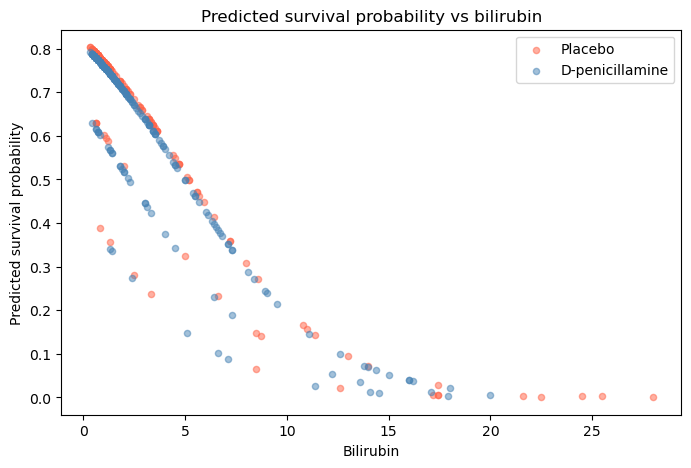


Logistic regression confusion matrix:
[[ 70  91]
 [ 21 236]]
Accuracy: 0.7320574162679426


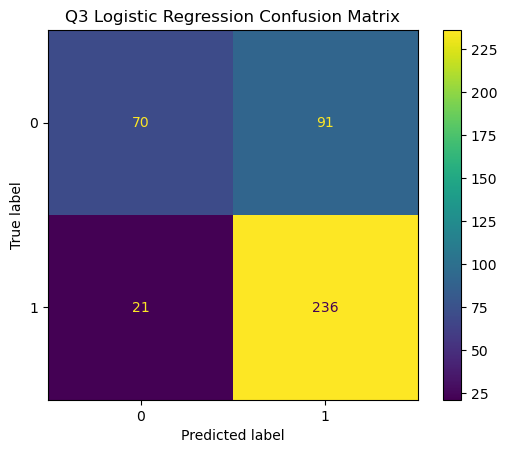


Linear model accuracy: 0.7248803827751196
Range of linear-model predictions: (-0.4889575516950292, 0.7811518255286405)


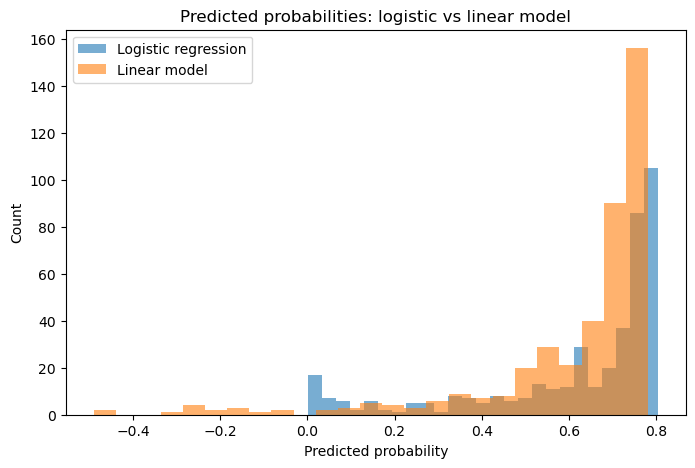


Stage confusion matrix (rows=true, cols=predicted):
   1  2    3   4
1  0  0   20   1
2  0  0   82  10
3  0  0  139  22
4  0  0   95  49

Predicted classes used by hard classification:
3    336
4     82
Name: count, dtype: int64

First five predicted probability rows:
          1         2         3         4
0  0.000001  0.033033  0.120736  0.846229
1  0.069329  0.252605  0.408072  0.269993
2  0.031742  0.128762  0.340004  0.499492
3  0.028019  0.126831  0.338437  0.506712
4  0.035396  0.242244  0.415653  0.306707


/home/trj/miniconda3/envs/hmm/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

# Part 1: load data and keep only the variables we need.
df = pd.read_csv('cirrhosis.csv')
cols = ['Edema', 'Drug', 'Bilirubin', 'Stage', 'Status']
df = df[cols].copy()

print('Missing values by column:')
print(df.isna().sum())

# Fill missing predictors before creating dummy variables.
df['Drug'] = df['Drug'].fillna(df['Drug'].mode()[0])
df['Stage'] = df['Stage'].fillna(df['Stage'].median())

# For parts 2-5, define survival as 1 for C or CL and 0 for D.
df['survival'] = df['Status'].isin(['C', 'CL']).astype(int)

# Set categories explicitly so dummy-variable columns stay consistent.
df['Edema'] = pd.Categorical(df['Edema'], categories=['N', 'S', 'Y'])
df['Drug'] = pd.Categorical(df['Drug'], categories=['D-penicillamine', 'Placebo'])

features = ['Edema', 'Drug', 'Bilirubin']
X = df[features].copy()
y = df['survival']

X_encoded = pd.get_dummies(X, columns=['Edema', 'Drug'], drop_first=True)

# Part 2: logistic regression of survival on edema, drug, and bilirubin.
logit = LogisticRegression(max_iter=2000)
logit.fit(X_encoded, y)

coef_table = pd.DataFrame({'feature': X_encoded.columns, 'coefficient': logit.coef_[0]})
print('\nLogistic regression coefficients:')
print(coef_table)

# Part 3: predicted probabilities and drug comparison.
df['survival_prob_logit'] = logit.predict_proba(X_encoded)[:, 1]

X_placebo = X.copy()
X_placebo['Drug'] = pd.Categorical(['Placebo'] * len(X_placebo), categories=['D-penicillamine', 'Placebo'])
X_placebo = pd.get_dummies(X_placebo, columns=['Edema', 'Drug'], drop_first=True)
X_placebo = X_placebo.reindex(columns=X_encoded.columns, fill_value=0)

X_drug = X.copy()
X_drug['Drug'] = pd.Categorical(['D-penicillamine'] * len(X_drug), categories=['D-penicillamine', 'Placebo'])
X_drug = pd.get_dummies(X_drug, columns=['Edema', 'Drug'], drop_first=True)
X_drug = X_drug.reindex(columns=X_encoded.columns, fill_value=0)

df['survival_if_placebo'] = logit.predict_proba(X_placebo)[:, 1]
df['survival_if_drug'] = logit.predict_proba(X_drug)[:, 1]
df['drug_effect'] = df['survival_if_drug'] - df['survival_if_placebo']

print('\nAverage drug effect on survival probability:')
print(df['drug_effect'].mean())

bilirubin_effect = pd.qcut(df['Bilirubin'], q=5, duplicates='drop')
print('\nAverage drug effect within bilirubin quintiles:')
print(df.groupby(bilirubin_effect, observed=False)['drug_effect'].mean())

plt.figure(figsize=(8, 5))
for drug_name, color in [('Placebo', 'tomato'), ('D-penicillamine', 'steelblue')]:
    mask = df['Drug'] == drug_name
    plt.scatter(
        df.loc[mask, 'Bilirubin'],
        df.loc[mask, 'survival_prob_logit'],
        alpha=0.5,
        s=20,
        label=drug_name,
        color=color,
    )
plt.xlabel('Bilirubin')
plt.ylabel('Predicted survival probability')
plt.title('Predicted survival probability vs bilirubin')
plt.legend()
plt.show()

# Part 4: confusion matrix and accuracy.
logit_pred = logit.predict(X_encoded)
print('\nLogistic regression confusion matrix:')
print(confusion_matrix(y, logit_pred))
print('Accuracy:', accuracy_score(y, logit_pred))
ConfusionMatrixDisplay.from_predictions(y, logit_pred)
plt.title('Q3 Logistic Regression Confusion Matrix')
plt.show()

# Part 5: compare logistic and linear models.
linear_model = LinearRegression()
linear_model.fit(X_encoded, y)
df['survival_prob_linear'] = linear_model.predict(X_encoded)
linear_pred = (df['survival_prob_linear'] >= 0.5).astype(int)

print('\nLinear model accuracy:', accuracy_score(y, linear_pred))
print('Range of linear-model predictions:', (df['survival_prob_linear'].min(), df['survival_prob_linear'].max()))

plt.figure(figsize=(8, 5))
plt.hist(df['survival_prob_logit'], bins=25, alpha=0.6, label='Logistic regression')
plt.hist(df['survival_prob_linear'], bins=25, alpha=0.6, label='Linear model')
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Predicted probabilities: logistic vs linear model')
plt.legend()
plt.show()

# Part 6: multinomial logistic regression of stage on edema and bilirubin.
stage_df = df[['Edema', 'Bilirubin', 'Stage']].dropna().copy()
stage_df['Edema'] = pd.Categorical(stage_df['Edema'], categories=['N', 'S', 'Y'])
X_stage = stage_df[['Edema', 'Bilirubin']].copy()
y_stage = stage_df['Stage'].astype(int).astype(str)
X_stage_encoded = pd.get_dummies(X_stage, columns=['Edema'], drop_first=True)

stage_model = LogisticRegression(max_iter=4000, penalty=None)
stage_model.fit(X_stage_encoded, y_stage)

stage_pred = stage_model.predict(X_stage_encoded)
stage_probs = stage_model.predict_proba(X_stage_encoded)
stage_classes = stage_model.classes_

print('\nStage confusion matrix (rows=true, cols=predicted):')
print(pd.DataFrame(confusion_matrix(y_stage, stage_pred, labels=stage_classes), index=stage_classes, columns=stage_classes))
print('\nPredicted classes used by hard classification:')
print(pd.Series(stage_pred).value_counts())
print('\nFirst five predicted probability rows:')
print(pd.DataFrame(stage_probs[:5], columns=stage_classes))


**Example discussion for Q3**

`Drug` has missing values in this dataset, so this solution fills them with the most common category before making dummy variables. `Stage` also has a few missing values; it is filled with the median for the early descriptive work, and rows with missing `Stage` are dropped in part 6 when `Stage` is the target.

In the survival model, the coefficient on `Bilirubin` is negative, so higher bilirubin predicts lower survival probability. The edema coefficients are also negative, with `Y` more negative than `S`, so more severe edema predicts lower survival. The coefficient for `Drug_Placebo` is slightly positive, which means the fitted model gives placebo a very small advantage over D-penicillamine in this sample.

Using `.predict_proba`, the estimated average treatment effect of D-penicillamine relative to placebo is about `-0.012` on survival probability, so the model does not suggest a survival benefit from the drug here. The effect is slightly negative across all bilirubin quintiles, so there is no clear bilirubin region where the drug improves survival in this fitted model.

The logistic-regression classifier has an accuracy of about `0.722`. The linear model is very similar at about `0.725`, but its predicted values go below `0`, which again shows why logistic regression is the better probability model.

For the multinomial stage model, the hard predictions only choose stages `3` and `4`; they never predict stages `1` or `2` as the most likely class. But the `.predict_proba` output still assigns nonzero probability to all four stages, so the soft probabilities contain more detail than the hard labels.


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

**Example solution for Q4**

1. In the linear model,
   $$
   \hat{y} = b_0 + \sum_{k=1}^K b_k x_k,
   $$
   so
   $$
   \frac{\partial \hat{y}}{\partial x_k} = b_k.
   $$
   A one-unit increase in `x_k` changes the prediction by exactly `b_k`, holding the other variables fixed.

2. In logistic regression,
   $$
   \hat{p} = \frac{e^{b \cdot x}}{1+e^{b \cdot x}}.
   $$
   Using the chain rule,
   $$
   \frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1-\hat{p}) b_k.
   $$
   Unlike the linear-model case, this depends on the current predicted probability. So the same coefficient can imply different changes in probability at different points in the feature space. The factor `\hat{p}(1-\hat{p})` is largest when `\hat{p}=0.5`, where it equals `0.25`. That means near `\hat{p}=0.5`, the coefficient times about `1/4` gives a rough estimate of the change in probability for a one-unit increase in `x_k`. Equivalently, `4 \times \partial \hat{p}/\partial x_k \approx b_k` near `\hat{p}=0.5`.

3. From the log-odds form,
   $$
   \log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_0 + \sum_{k=1}^K b_k x_k,
   $$
   we get
   $$
   \frac{\partial}{\partial x_k} \log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_k.
   $$
   So a one-unit increase in `x_k` changes the log-odds ratio by exactly `b_k`. This is the cleanest direct interpretation of a logistic-regression coefficient.
